# 🌊 Style Trajectory Analysis v2

## 슬라이딩 윈도우 + POS 시퀀스 + GRU 모델

**핵심**:
- 각 윈도우에서 Feature 추출 → 시퀀스
- POS 분석도 윈도우별로!
- GRU (또는 1D CNN + GRU)로 학습

```
글 → [W1, W2, W3, ...] (윈도우 시퀀스)
         ↓
     각 윈도우: [문장길이, TTR, 쉼표, 명사비율, 동사비율, ...]
         ↓
     shape: (num_windows, num_features)
         ↓
     GRU → AI/Human 분류
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 기본 라이브러리 로드")

✅ 기본 라이브러리 로드


In [1]:
%pip install konlpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# POS 분석기 (Okt 사용 - 설치 필요시: pip install konlpy)
try:
    from konlpy.tag import Okt
    okt = Okt()
    USE_POS = True
    print("✅ Okt 형태소 분석기 로드")
except:
    USE_POS = False
    print("⚠️  Okt 없음 - 간이 POS 분석 사용")
    print("   설치: pip install konlpy")

⚠️  Okt 없음 - 간이 POS 분석 사용
   설치: pip install konlpy


## 📊 데이터 로드

In [4]:
df = pd.read_csv('/Users/youngjinson/Downloads/open/train.csv')

print(f"전체: {len(df):,}")
print(df['generated'].value_counts())

# 샘플 (가볍게)
ai_samples = df[df['generated'] == 1].sample(20, random_state=42)
human_samples = df[df['generated'] == 0].sample(20, random_state=42)

print(f"\n샘플: AI {len(ai_samples)}, Human {len(human_samples)}")

전체: 97,172
generated
0    89177
1     7995
Name: count, dtype: int64

샘플: AI 20, Human 20


## 🛠️ Feature 추출 함수

In [5]:
def split_sentences(text):
    """문장 분할"""
    sentences = re.split(r'[.!?]+', str(text))
    return [s.strip() for s in sentences if s.strip()]

def extract_pos_features(text):
    """
    POS 분석 - 윈도우별로 사용
    
    Returns:
        dict: 품사별 비율
    """
    if USE_POS:
        try:
            pos_tags = okt.pos(text)
            pos_counts = Counter([tag for word, tag in pos_tags])
            total = max(len(pos_tags), 1)
            
            return {
                'noun_ratio': pos_counts.get('Noun', 0) / total,
                'verb_ratio': pos_counts.get('Verb', 0) / total,
                'adj_ratio': pos_counts.get('Adjective', 0) / total,
                'josa_ratio': pos_counts.get('Josa', 0) / total,
                'eomi_ratio': pos_counts.get('Eomi', 0) / total,
                'adverb_ratio': pos_counts.get('Adverb', 0) / total,
                'punct_ratio': pos_counts.get('Punctuation', 0) / total,
            }
        except:
            pass
    
    # 간이 분석 (Okt 없을 때)
    words = text.split()
    total = max(len(words), 1)
    
    # 패턴 기반
    formal_endings = ['습니다', '입니다', '됩니다', '합니다']
    informal = ['ㅋ', 'ㅎ', 'ㅠ', ';;']
    conjunctions = ['따라서', '그러나', '그리고', '또한', '하지만']
    
    formal_count = sum(text.count(e) for e in formal_endings)
    informal_count = sum(text.count(p) for p in informal)
    conj_count = sum(text.count(c) for c in conjunctions)
    
    return {
        'noun_ratio': 0.3,  # placeholder
        'verb_ratio': 0.2,
        'adj_ratio': 0.1,
        'josa_ratio': 0.15,
        'eomi_ratio': formal_count / total,
        'adverb_ratio': conj_count / total,
        'punct_ratio': informal_count / total,
    }

def extract_window_features(text):
    """
    한 윈도우(텍스트 조각)에서 모든 Feature 추출
    
    Returns:
        list: [feat1, feat2, ...] 숫자 리스트
    """
    sentences = split_sentences(text)
    words = text.split()
    
    # 1. 문장 길이 통계
    sent_lengths = [len(s) for s in sentences] if sentences else [0]
    avg_sent_len = np.mean(sent_lengths)
    std_sent_len = np.std(sent_lengths) if len(sent_lengths) > 1 else 0
    
    # 2. 어휘 다양성 (TTR)
    ttr = len(set(words)) / max(len(words), 1)
    
    # 3. 쉼표 밀도
    comma_density = text.count(',') / max(len(sentences), 1)
    
    # 4. 반복 표현율
    word_counts = Counter(words)
    repeated = sum(1 for w, c in word_counts.items() if c >= 2)
    repetition_rate = repeated / max(len(word_counts), 1)
    
    # 5. POS 분석
    pos_feats = extract_pos_features(text)
    
    # 합치기 (순서 고정!)
    features = [
        avg_sent_len,
        std_sent_len,
        ttr,
        comma_density,
        repetition_rate,
        pos_feats['noun_ratio'],
        pos_feats['verb_ratio'],
        pos_feats['adj_ratio'],
        pos_feats['josa_ratio'],
        pos_feats['eomi_ratio'],
        pos_feats['adverb_ratio'],
    ]
    
    return features

FEATURE_NAMES = [
    'avg_sent_len', 'std_sent_len', 'ttr', 'comma_density', 'repetition',
    'noun', 'verb', 'adj', 'josa', 'eomi', 'adverb'
]

print(f"✅ Feature 함수 정의 완료 ({len(FEATURE_NAMES)}개 feature)")

✅ Feature 함수 정의 완료 (11개 feature)


## 🌊 슬라이딩 윈도우 시퀀스 추출

In [6]:
def extract_feature_sequence(text, window_size=5, stride=2):
    """
    글 전체 → Feature 시퀀스
    
    Args:
        text: 전체 텍스트
        window_size: 윈도우당 문장 수
        stride: 이동 간격
    
    Returns:
        np.array: (num_windows, num_features)
    """
    sentences = split_sentences(text)
    
    if len(sentences) < window_size:
        # 문장 적으면 전체를 하나로
        return np.array([extract_window_features(text)])
    
    sequences = []
    for i in range(0, len(sentences) - window_size + 1, stride):
        window_text = ' '.join(sentences[i:i + window_size])
        features = extract_window_features(window_text)
        sequences.append(features)
    
    return np.array(sequences)

# 테스트
sample_text = ai_samples.iloc[0]['full_text']
seq = extract_feature_sequence(sample_text)

print(f"입력 텍스트 길이: {len(sample_text)}")
print(f"시퀀스 shape: {seq.shape}")
print(f"  → {seq.shape[0]} 윈도우 x {seq.shape[1]} features")

입력 텍스트 길이: 738
시퀀스 shape: (5, 11)
  → 5 윈도우 x 11 features


## 📈 시각화: AI vs Human 시퀀스 비교

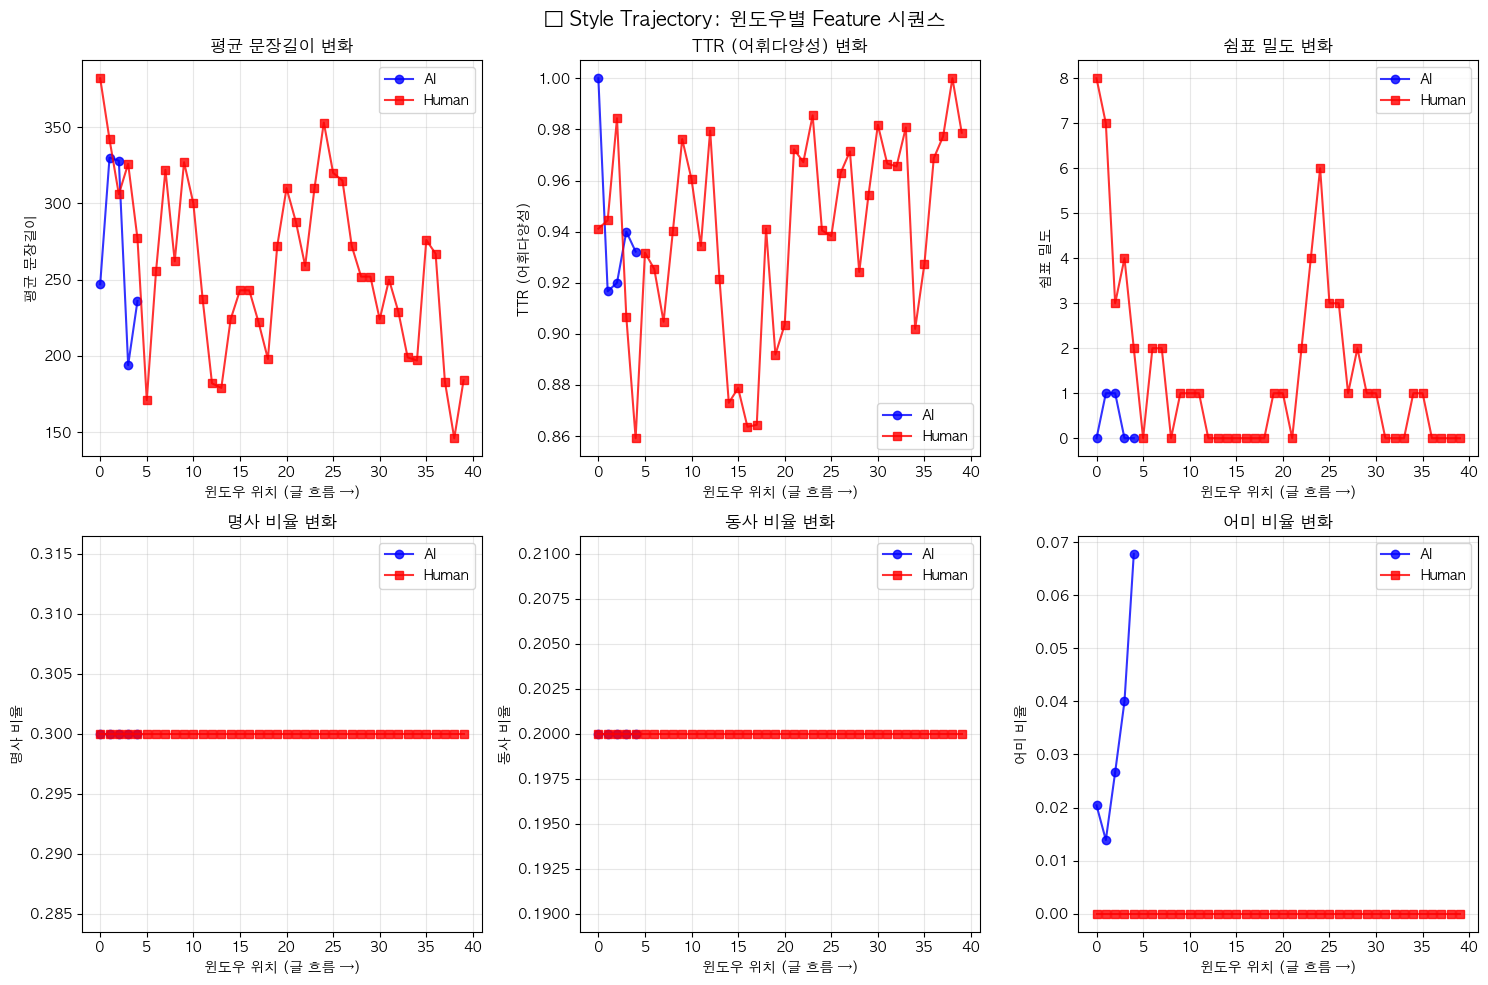

In [7]:
# 샘플 하나씩
ai_seq = extract_feature_sequence(ai_samples.iloc[0]['full_text'])
human_seq = extract_feature_sequence(human_samples.iloc[0]['full_text'])

# 주요 Feature 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features_to_plot = [0, 2, 3, 5, 6, 9]  # avg_len, ttr, comma, noun, verb, eomi
titles = ['평균 문장길이', 'TTR (어휘다양성)', '쉼표 밀도', '명사 비율', '동사 비율', '어미 비율']

for idx, (feat_idx, title) in enumerate(zip(features_to_plot, titles)):
    ax = axes[idx // 3, idx % 3]
    
    ax.plot(range(len(ai_seq)), ai_seq[:, feat_idx], 'b-o', label='AI', alpha=0.8)
    ax.plot(range(len(human_seq)), human_seq[:, feat_idx], 'r-s', label='Human', alpha=0.8)
    
    ax.set_xlabel('윈도우 위치 (글 흐름 →)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} 변화')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('🌊 Style Trajectory: 윈도우별 Feature 시퀀스', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

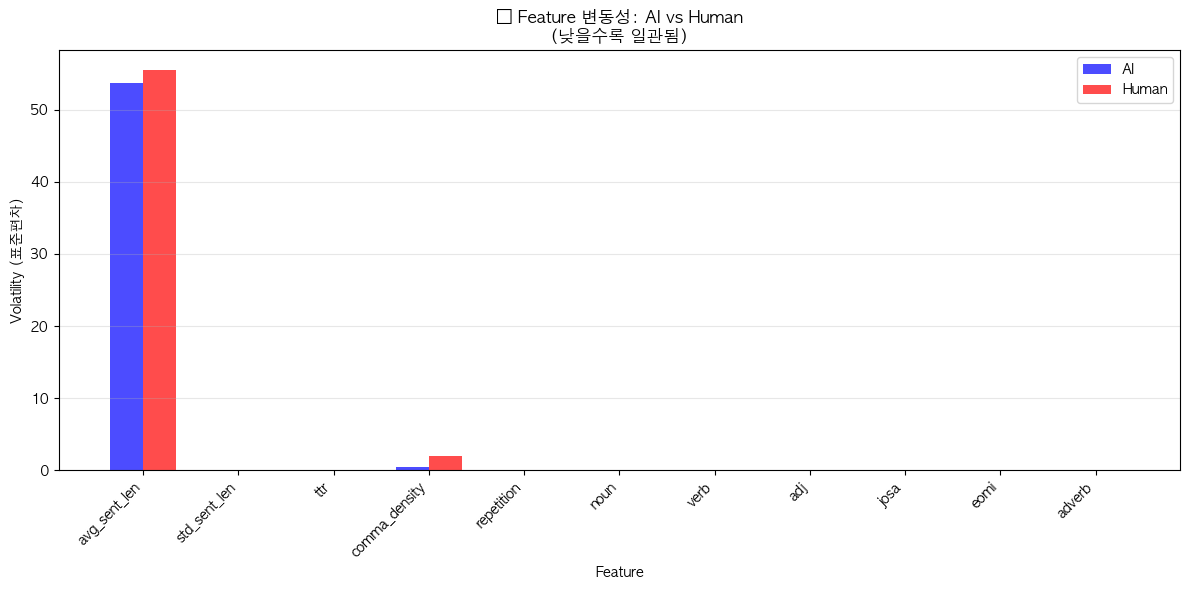

In [8]:
# 변동성 (Volatility) 비교
def calc_volatility(seq):
    """각 feature의 표준편차"""
    if len(seq) <= 1:
        return np.zeros(seq.shape[1])
    return np.std(seq, axis=0)

ai_vol = calc_volatility(ai_seq)
human_vol = calc_volatility(human_seq)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(FEATURE_NAMES))
width = 0.35

ax.bar(x - width/2, ai_vol, width, label='AI', color='blue', alpha=0.7)
ax.bar(x + width/2, human_vol, width, label='Human', color='red', alpha=0.7)

ax.set_xlabel('Feature')
ax.set_ylabel('Volatility (표준편차)')
ax.set_title('🎯 Feature 변동성: AI vs Human\n(낮을수록 일관됨)')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 📊 전체 샘플 분석

In [ ]:
from tqdm import tqdm

def analyze_all_samples(samples, label):
    """모든 샘플의 변동성 계산"""
    results = []
    
    for _, row in tqdm(samples.iterrows(), total=len(samples), desc=label):
        seq = extract_feature_sequence(row['full_text'])
        vol = calc_volatility(seq)
        
        result = {'label': label, 'num_windows': len(seq)}
        for i, name in enumerate(FEATURE_NAMES):
            result[f'{name}_vol'] = vol[i]
        
        results.append(result)
    
    return results

ai_results = analyze_all_samples(ai_samples, 'AI')
human_results = analyze_all_samples(human_samples, 'Human')

all_results = pd.DataFrame(ai_results + human_results)
print(f"\n분석 완료: {len(all_results)}개")

In [ ]:
# 그룹별 평균 변동성
vol_cols = [c for c in all_results.columns if '_vol' in c]

print("📊 Feature별 변동성 비교:")
print("="*60)
print(f"{'Feature':<20} {'AI (평균)':>12} {'Human (평균)':>12} {'차이':>10}")
print("-"*60)

for col in vol_cols:
    ai_mean = all_results[all_results['label'] == 'AI'][col].mean()
    human_mean = all_results[all_results['label'] == 'Human'][col].mean()
    diff = human_mean - ai_mean
    
    feat_name = col.replace('_vol', '')
    marker = "⬆️" if diff > 0 else "⬇️"
    print(f"{feat_name:<20} {ai_mean:>12.4f} {human_mean:>12.4f} {diff:>+10.4f} {marker}")

In [ ]:
# 박스플롯
key_features = ['avg_sent_len_vol', 'ttr_vol', 'noun_vol', 'verb_vol']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, feat in enumerate(key_features):
    all_results.boxplot(column=feat, by='label', ax=axes[idx])
    axes[idx].set_title(feat.replace('_vol', '') + ' 변동성')
    axes[idx].set_xlabel('')

plt.suptitle('🎯 AI vs Human: 스타일 변동성 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 GRU 모델 정의

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class StyleSequenceDataset(Dataset):
    """스타일 시퀀스 데이터셋"""
    def __init__(self, texts, labels, max_windows=50):
        self.sequences = []
        self.labels = []
        self.max_windows = max_windows
        
        for text, label in zip(texts, labels):
            seq = extract_feature_sequence(text)
            self.sequences.append(seq)
            self.labels.append(label)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]
        
        # 패딩/자르기
        if len(seq) > self.max_windows:
            seq = seq[:self.max_windows]
        elif len(seq) < self.max_windows:
            pad = np.zeros((self.max_windows - len(seq), seq.shape[1]))
            seq = np.vstack([seq, pad])
        
        return torch.FloatTensor(seq), torch.FloatTensor([label])

print("✅ Dataset 클래스 정의")

In [ ]:
class StyleGRU(nn.Module):
    """GRU 기반 스타일 분류기"""
    def __init__(self, input_dim=11, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.gru = nn.GRU(
            input_dim, hidden_dim, num_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: (batch, seq_len, features)
        out, hidden = self.gru(x)
        
        # 마지막 hidden state (forward + backward)
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        
        return self.fc(last_hidden)

class HybridCNNGRU(nn.Module):
    """1D CNN + GRU 하이브리드"""
    def __init__(self, input_dim=11, hidden_dim=64, dropout=0.3):
        super().__init__()
        
        # CNN: 지역 패턴
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        
        # GRU: 순서 학습
        self.gru = nn.GRU(64, hidden_dim, batch_first=True, bidirectional=True)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)
        
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        
        x = x.permute(0, 2, 1)  # (batch, seq_len, 64)
        
        out, hidden = self.gru(x)
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        
        return self.fc(last_hidden)

print("✅ 모델 클래스 정의")
print("  - StyleGRU: 순수 GRU")
print("  - HybridCNNGRU: 1D CNN + GRU")

## 🚀 모델 테스트

In [ ]:
# 데이터 준비
all_texts = list(ai_samples['full_text']) + list(human_samples['full_text'])
all_labels = [1] * len(ai_samples) + [0] * len(human_samples)

print(f"데이터: {len(all_texts)}개 (AI: {sum(all_labels)}, Human: {len(all_labels) - sum(all_labels)})")

# Dataset
dataset = StyleSequenceDataset(all_texts, all_labels, max_windows=30)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# 모델
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridCNNGRU(input_dim=11, hidden_dim=64)  # 또는 StyleGRU
model = model.to(device)

print(f"\nDevice: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# 간단한 학습 테스트 (5 epochs)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

model.train()
for epoch in range(5):
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss/len(loader):.4f}, Acc={acc:.4f}")

## 🎯 결론

In [ ]:
print("""
═══════════════════════════════════════════════════════════════
🎯 핵심 발견
═══════════════════════════════════════════════════════════════

1. 슬라이딩 윈도우로 "글의 흐름"을 시퀀스로 표현
   → 각 윈도우에서 다양한 Feature 추출
   → POS 분석도 윈도우별로!

2. AI vs Human의 차이:
   - AI: 처음부터 끝까지 일관된 스타일 (낮은 변동성)
   - Human: 스타일이 들쭉날쭉 (높은 변동성)

3. GRU (또는 1D CNN + GRU) 모델로 학습:
   - 입력: (batch, num_windows, num_features)
   - 순서 정보를 활용하여 분류

═══════════════════════════════════════════════════════════════
🚀 다음 단계
═══════════════════════════════════════════════════════════════

1. 더 많은 데이터로 본격 학습
2. BERT 임베딩 + 이 Feature 시퀀스 앙상블
3. 변동성 지표를 설명가능성 근거로 활용
""")